In [1]:
# --! include root folders into PYTHONPATH --!

import os
import sys

dir_this = os.getcwd()
dir_example = os.path.abspath(os.path.join(dir_this, '..'))
sys.path.append(dir_example)
dir_root = os.path.abspath(os.path.join(dir_this, '..', '..', '..'))
sys.path.append(dir_root)

import torch
import torch.nn.functional as F
import numpy as np
from matplotlib import pyplot as plt

import example_mujoco
import util_data
import util_nn
import kind

data_path = '../../../data/mujoco'
model_path = '../../../models/mujoco'
result_path = '../../../results/mujoco'

In [2]:
# --! specify kind arguments

parser = kind.create_args_parser()
args = parser.parse_args(
    args=[
        '--file_dir', data_path,
        '--file_name', 'walker2d',
        '--data_nsample_baseline', '918',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--obs_ndim', '17',
        '--act_ndim', '6',
        '--target_ndim', '17',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '1000',
        '--patience', '100',
        '--checkpoints', f'{model_path}/walker2d',

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 10, "cos": 10}',
        '--embed_exc', '{"data": 20}',
    ]
)

# --! instantiate a KIND model
model = kind.model(args)

# --! load trained weights into the model
model_path = args.checkpoints + '/' + '20260325_kind_checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

setpoint = torch.zeros(args.target_ndim)

dataset = example_mujoco.dataset(args, setpoint, load_normalized=False, extract_windows=False)
model = kind.model_adapter(model, dataset.normalizer)

read data shape: torch.Size([80, 918, 23])
current trajectory shape: torch.Size([1, 918, 23])


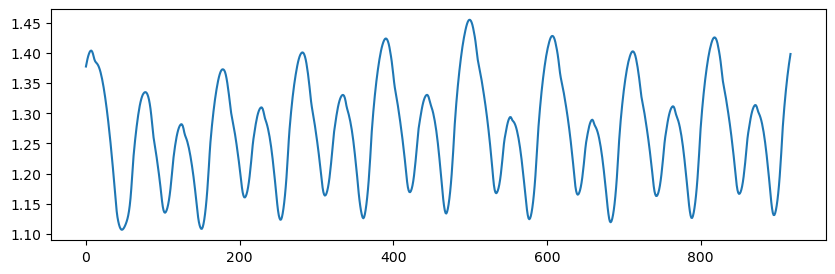

In [58]:
jdata = 18

trajectories_true = util_data.read_datafile(f'{data_path}/walker2d_baseline_0', args.data_nsample_baseline)
print(f'read data shape: {trajectories_true.shape}')

traj_true = trajectories_true[[jdata]]
print(f'current trajectory shape: {traj_true.shape}')

plt.figure(figsize=(10,3))
plt.plot(traj_true[0, :, 0])
plt.show()

In [59]:
# --! perform model rollout --!

offset = 0
h = 800 # rollout length, horizon
reset_nsample = 1_000 # re-anchor after this number of samples

true, next_ss, alphas, zetas_nom, zetas_exc, means_nom, means_exc = example_mujoco.rollout_kind(
    model,
    traj_true,
    horizon=h, reset_nsample=reset_nsample, offset=offset)


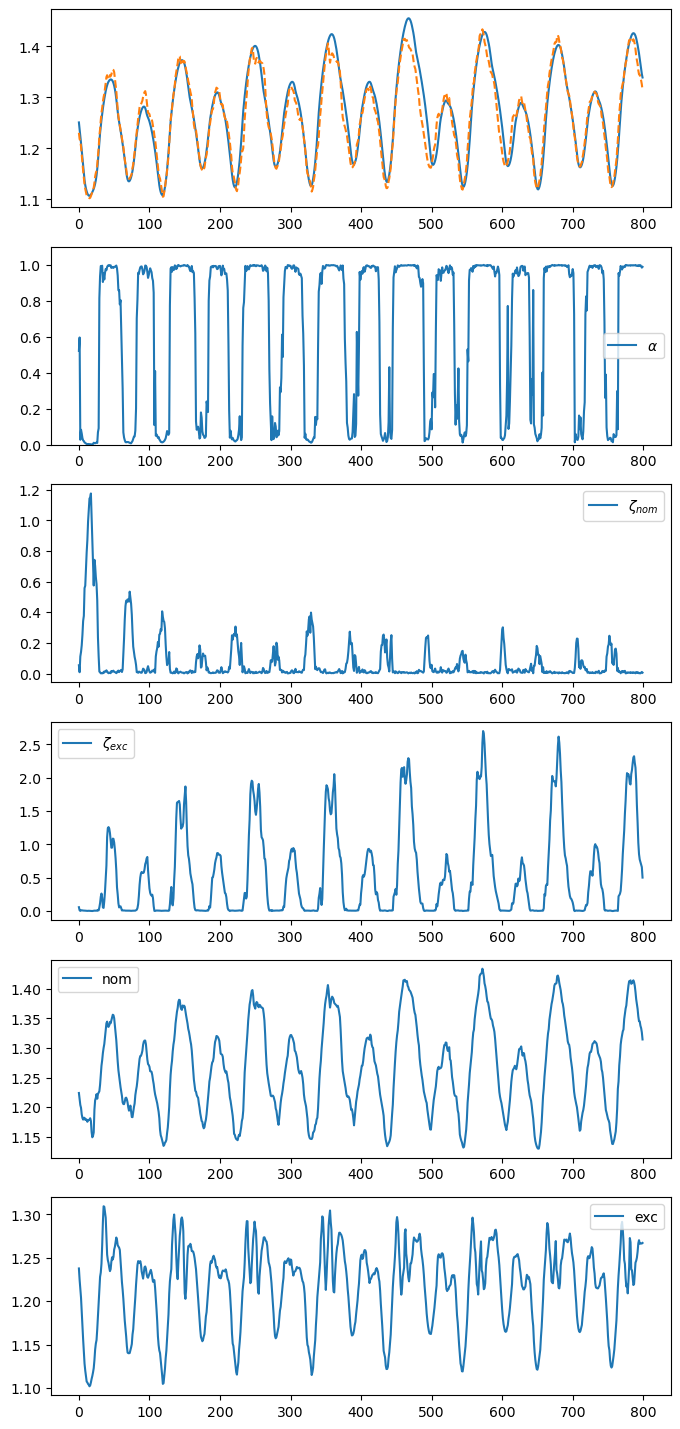

In [60]:
# --! plot rollout results

with torch.no_grad():
    plt.figure(figsize=(8,18))

    plt.subplot(6,1,1)
    plt.plot(true[0, :, 0])
    plt.plot(next_ss[0, :, 0], linestyle='dashed')

    plt.subplot(6,1,2)
    plt.plot(alphas[0, :, 0], label='$\\alpha$')
    plt.ylim((0.0, 1.1))
    plt.legend()

    plt.subplot(6,1,3)
    plt.plot(zetas_nom[0, :, 0], label='$\\zeta_{nom}$')
    plt.legend()

    plt.subplot(6,1,4)
    plt.plot(zetas_exc[0, :, 0], label='$\\zeta_{exc}$')
    plt.legend()

    plt.subplot(6,1,5)
    plt.plot(means_nom[0, :, 0], label='nom')
    plt.legend()

    plt.subplot(6,1,6)
    plt.plot(means_exc[0, :, 0], label='exc')
    plt.legend()

    plt.show()

### Saving rollout data

In [15]:
datasaved = False

if datasaved:
    step = torch.arange(true.shape[1]).reshape(1, -1, 1)
    savedata = np.concatenate([
        step,
        true[..., :1], next_ss[..., :1],
        alphas[..., :1], zetas_nom[..., :1], zetas_exc[..., :1],
        means_nom[..., :1], means_exc[..., :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_kind_rollout_reanchor_none', savedata, delim=' ')

### Analyzing mse vs. horizon

In [7]:
# --! compute mse vs. horizon

traj_mse = []
with torch.no_grad():
    for j in range(trajectories_true.shape[0]): # trajectory
        print(f'processing trajectory {j+1} out of {trajectories_true.shape[0]}')
        mse = []
        for h in range(1, trajectories_true.shape[1] - args.back_nsample): # horizon, account for lookback window!
            traj_true = trajectories_true[[j]]
            rollout_o = example_mujoco.rollout_kind(model, traj_true, horizon=h, reset_nsample=reset_nsample)
            true = rollout_o[0]
            next_ss = rollout_o[1]
            true_obs = true[..., :args.obs_ndim]

            loss = F.mse_loss(next_ss, true_obs)
            mse.append(loss)
            if h % 100 == 0:
                print(f'\thorizon {h} out of {trajectories_true.shape[1] - args.back_nsample}, loss: {loss}')
        mse = torch.stack(mse)
        traj_mse.append(mse)
    traj_mse = torch.stack(traj_mse)

processing trajectory 1 out of 80
	horizon 100 out of 886, loss: 0.6311308741569519
	horizon 200 out of 886, loss: 0.5088837146759033
	horizon 300 out of 886, loss: 0.5566840171813965
	horizon 400 out of 886, loss: 1.1579408645629883
	horizon 500 out of 886, loss: 2.3980228900909424
	horizon 600 out of 886, loss: 3.631240129470825
	horizon 700 out of 886, loss: 5.000646114349365
	horizon 800 out of 886, loss: 5.868514537811279
processing trajectory 2 out of 80
	horizon 100 out of 886, loss: 0.3447853624820709


KeyboardInterrupt: 

In [ ]:
traj_mse_mean = torch.mean(traj_mse, dim=0)
traj_mse_std = torch.std(traj_mse, dim=0)

print(traj_mse_mean[0])
print(traj_mse_std[0])

with torch.no_grad():
    plt.figure(figsize=(6,3))
    plt.semilogy(traj_mse_mean)
    plt.xlabel('Rollout horizon')
    plt.ylabel('mse')
    plt.show()

datasaved = False
if datasaved:
    save_mse_mean = traj_mse_mean.reshape(1, -1, 1)
    save_mse_std = traj_mse_std.reshape(1, -1, 1)
    save_step = torch.arange(traj_mse_mean.shape[0]).reshape(1, -1, 1)
    savedata = np.concatenate([
        save_step[:1, :, :1],
        save_mse_mean[:1, :, :1], save_mse_std[:1, :, :1]], axis=2)
    util_data.write_datafile(f'{result_path}/walker2d_kind_mse', savedata, delim=' ')